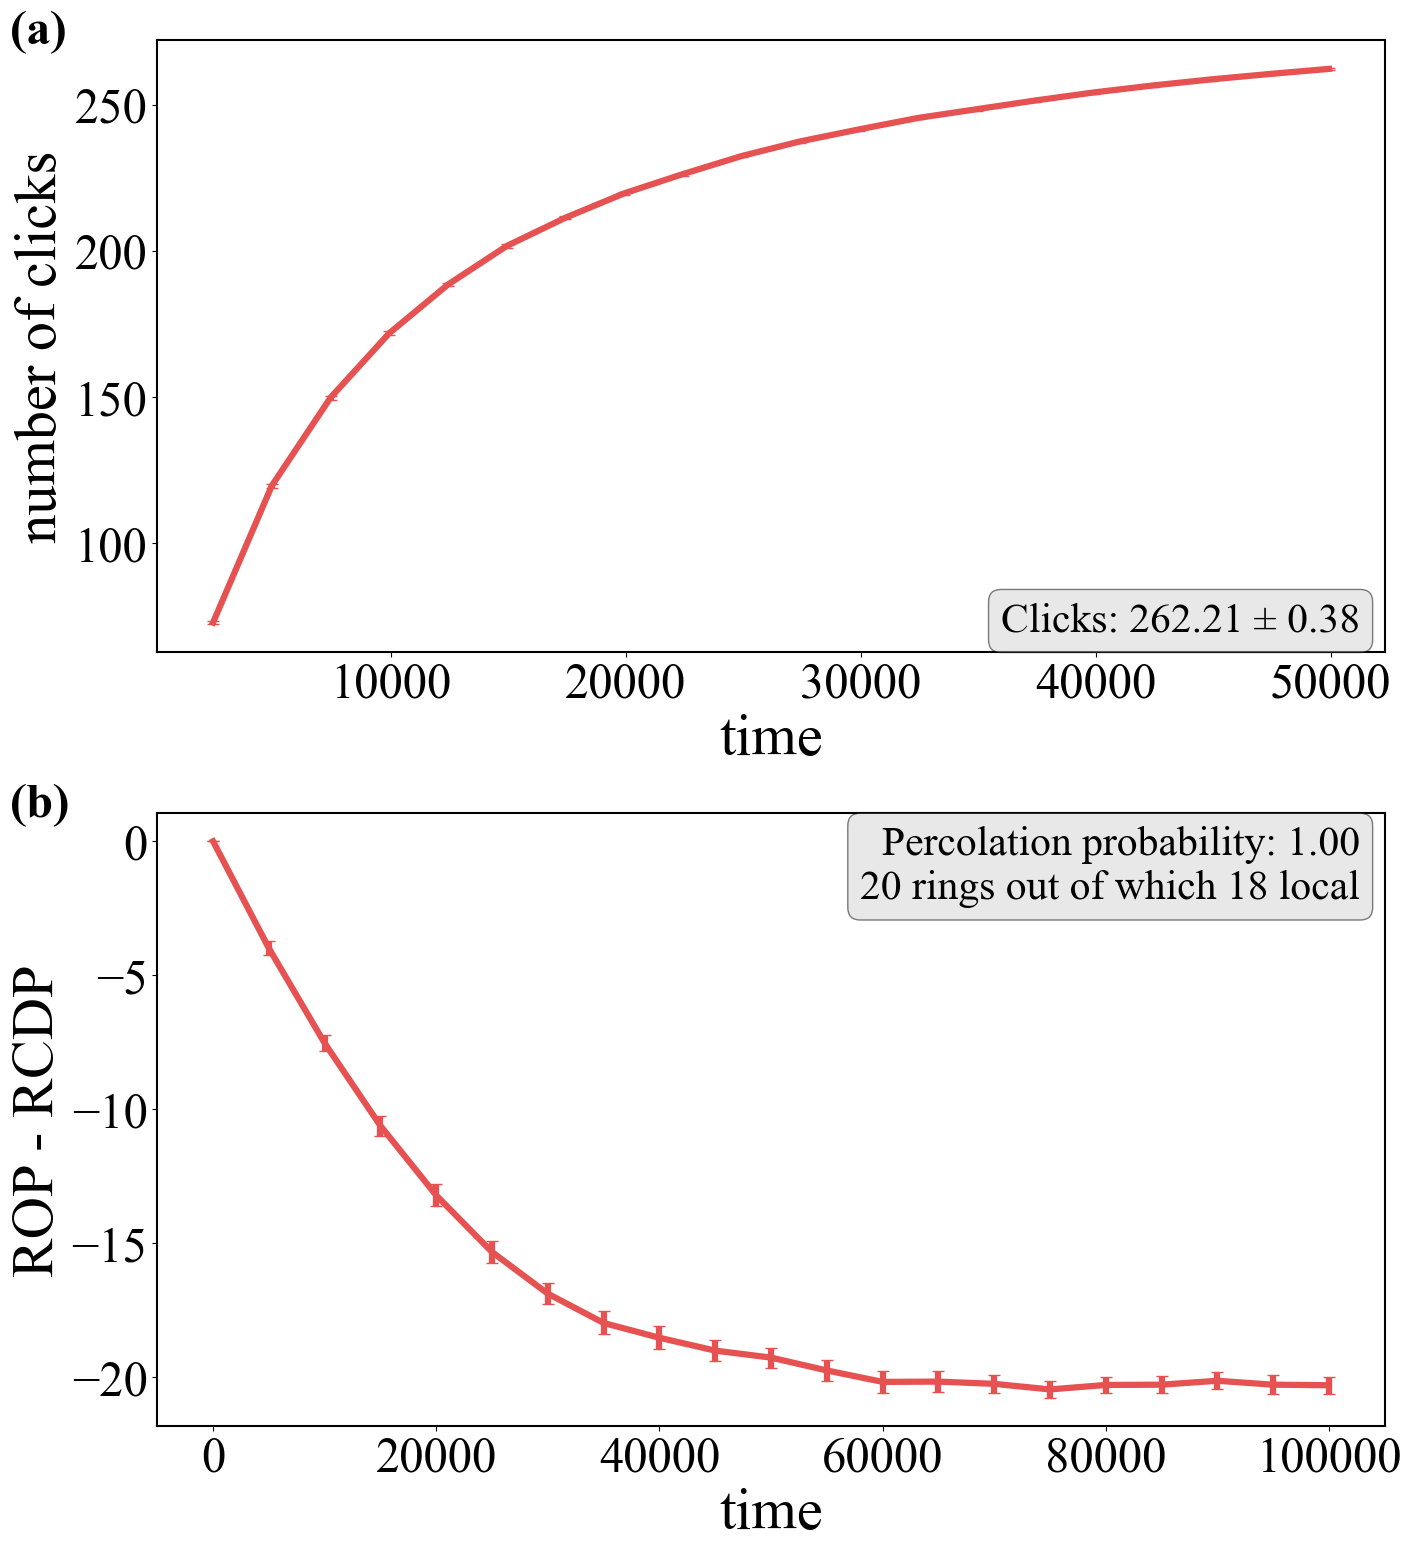

In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import networkx as nx
import perconet
import matplotlib as mpl

# ----------------------------
# Plot style (publication-ready)
# ----------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Computer Modern Roman"],
    "text.usetex": False,
    "axes.labelsize": 42,
    "axes.titlesize": 20,
    "legend.fontsize": 35,
    "lines.linewidth": 3.5,
    "lines.markersize": 8,
    "errorbar.capsize": 4,
    "axes.linewidth": 1.5,
})

color_line = "#e65151ff"  # red

# ----------------------------
# ----------------------------
# Panel (a) Top figure: 0_form_network
# ----------------------------
crosslink_folder_a = r"data\step_1_formation_by_click_chemistry\cross_links_c7"
percolation_folder_a = r"data\step_1_formation_by_click_chemistry\final_data_stars_c7"

# Load crosslink data
def load_crosslink_data(folder):
    files = sorted(glob(os.path.join(folder, "crosslink_c7_s*.txt")))
    all_data = [np.loadtxt(f, comments="#") for f in files]
    return np.array(all_data)

def compute_avg_sem(all_data):
    timesteps = all_data[0, :, 0]
    values = all_data[:, :, 1]
    avg = np.mean(values, axis=0)
    sem = np.std(values, axis=0, ddof=1)/np.sqrt(values.shape[0])
    return timesteps, avg, sem

all_data_a = load_crosslink_data(crosslink_folder_a)
timesteps_a, crosslink_avg, crosslink_sem = compute_avg_sem(all_data_a)
final_avg = crosslink_avg[-1]
final_sem = crosslink_sem[-1]

# Percolation + ring analysis
def analyze_percolation_counts(folder, pattern="datatarsnetwork_c7_s*.polymer", allowed_ids=None):
    files = sorted(glob(os.path.join(folder, pattern)))
    if allowed_ids is not None:
        files = [f for f in files if re.search(r"data_(\d+)", os.path.basename(f)).group(1) in set(allowed_ids)]
    N_files = len(files)
    if N_files == 0:
        raise RuntimeError("No polymer files found.")
    
    count_x = count_y = count_z = count_xyz = 0
    degree3_total = circle7_total = 0
    for data_file in files:
        with open(data_file, "r") as f:
            lines = f.readlines()
        # Box
        box = np.zeros(3)
        for line in lines:
            if "xlo xhi" in line: box[0] = float(line.split()[1]) - float(line.split()[0])
            if "ylo yhi" in line: box[1] = float(line.split()[1]) - float(line.split()[0])
            if "zlo zhi" in line: box[2] = float(line.split()[1]) - float(line.split()[0])
        # Atoms
        atom_start = next(i for i,l in enumerate(lines) if "Atoms" in l) + 2
        final_pos = []
        for i in range(atom_start, len(lines)):
            if lines[i].strip().startswith(("Bonds","Velocities","Masses")) or not lines[i].strip(): break
            final_pos.append(list(map(float, lines[i].split()[3:6])))
        final_pos = np.array(final_pos)
        # Bonds
        bond_start = next(i for i,l in enumerate(lines) if "Bonds" in l) + 2
        final_bonds = []
        for i in range(bond_start, len(lines)):
            if lines[i].strip().startswith(("Velocities","Atoms","Masses")) or not lines[i].strip(): break
            parts = lines[i].split()
            final_bonds.append((int(parts[2])-1, int(parts[3])-1))
        # Degree 3
        degree_count = np.zeros(len(final_pos), dtype=int)
        for a1,a2 in final_bonds:
            degree_count[a1] +=1
            degree_count[a2] +=1
        degree3_total += np.sum(degree_count==3)
        # 7-cycles
        G = nx.Graph()
        G.add_nodes_from(range(len(final_pos)))
        G.add_edges_from(final_bonds)
        cycles = nx.cycle_basis(G)
        circle7_total += sum(1 for c in cycles if len(c)==7)
        # Percolation
        topo = perconet.PeriodicNetwork(n=len(final_pos), verbose=False)
        for i,j in final_bonds:
            vec = final_pos[j]-final_pos[i]
            topo.add_edge(i,j,np.round(vec/box))
        loops,_ = perconet.LoopFinder(topo, verbose=False).get_independent_loops()
        loops = np.array(loops)
        if any(np.array_equal(loop,[1,0,0]) for loop in loops): count_x+=1
        if any(np.array_equal(loop,[0,1,0]) for loop in loops): count_y+=1
        if any(np.array_equal(loop,[0,0,1]) for loop in loops): count_z+=1
        if (any(np.array_equal(loop,[1,0,0]) for loop in loops) and
            any(np.array_equal(loop,[0,1,0]) for loop in loops) and
            any(np.array_equal(loop,[0,0,1]) for loop in loops)):
            count_xyz += 1
    prob_x = count_x/N_files
    prob_y = count_y/N_files
    prob_z = count_z/N_files
    prob_xyz = count_xyz/N_files
    return prob_x, prob_y, prob_z, prob_xyz, N_files, degree3_total/N_files, circle7_total/N_files

prob_x_a, prob_y_a, prob_z_a, prob_xyz_a, N_poly_a, degree3_avg_a, circle7_avg_a = analyze_percolation_counts(percolation_folder_a)

# ----------------------------
# Panel (b) Bottom figure: 1_relaxation
# ----------------------------
bond_folder_b = r"data\step2_relaxation_ROP\2bond_info_c7"
polymer_folder_b = r"data\step2_relaxation_ROP\2final_data_stars_c7"

bond_files = sorted(glob(os.path.join(bond_folder_b,"bond_info.reacter*.txt")))
polymer_files = sorted(glob(os.path.join(polymer_folder_b,"data_*.polymer")))

# Match ids
bond_map = {re.search(r"reacter(\d+)",os.path.basename(p)).group(1):p for p in bond_files}
poly_map = {re.search(r"data_(\d+)",os.path.basename(p)).group(1):p for p in polymer_files}

common_ids = sorted(set(bond_map.keys()) & set(poly_map.keys()), key=lambda x:int(x))

diff_all = []
time_points = None

for simid in common_ids:
    bond_path = bond_map[simid]
    data = np.loadtxt(bond_path)
    if data.ndim != 2 or data.shape[1]<4:
        raise RuntimeError(f"Bond file {bond_path} does not have 4 columns")
    breaking_on = data[:,0]
    breaking_off = data[:,1]
    forming = data[:,2]
    time = data[:,3]
    diff = forming - (breaking_on + breaking_off)
    diff_all.append(diff)
    if time_points is None:
        time_points = time

# Align lengths
min_len = min(len(d) for d in diff_all)
diff_all = np.array([d[:min_len] for d in diff_all])
time_points = time_points[:min_len]

# Compute average + SEM
diff_mean = np.mean(diff_all, axis=0)
diff_sem  = np.std(diff_all, axis=0, ddof=1)/np.sqrt(len(diff_all))

# Polymer analysis for matched runs
prob_x_b, prob_y_b, prob_z_b, prob_xyz_b, N_poly_b, degree3_avg_b, circle7_avg_b = analyze_percolation_counts(
    polymer_folder_b, pattern="data_*.polymer", allowed_ids=common_ids
)

# ----------------------------
# ----------------------------
# Plot final publication-style vertical figure
# ----------------------------
fig_width = 14  # cm
fig_height = fig_width * 0.55 * 2
fig, axs = plt.subplots(2,1,figsize=(fig_width, fig_height), constrained_layout=True)

# Panel (a) Top
axs[0].errorbar(
    timesteps_a, crosslink_avg, yerr=crosslink_sem,
    fmt='-', lw=4.5, elinewidth=4.5, capsize=4, color=color_line
)
axs[0].text(
    0.98,0.02,
    f'Clicks: {final_avg:.2f} ± {final_sem:.2f}',
    transform=axs[0].transAxes, fontsize=30, va='bottom', ha='right',
    bbox=dict(boxstyle="round", facecolor="lightgrey", alpha=0.5)
)
axs[0].set_xlabel("time")
axs[0].set_ylabel("number of clicks")
axs[0].text(-0.12,1.05,'(a)', transform=axs[0].transAxes, fontsize=35,fontweight='bold',va='top',ha='left')
axs[0].tick_params(labelsize=35)

# Panel (b) Bottom
axs[1].errorbar(
    time_points, diff_mean, yerr=diff_sem,
    fmt='-', lw=4.5, elinewidth=4.5, capsize=4, color=color_line
)

axs[1].text(
    0.98,0.98,
    f'Percolation probability: {prob_xyz_b:.2f}\n{degree3_avg_b:.0f} rings out of which {circle7_avg_b:.0f} local',
    transform=axs[1].transAxes, fontsize=30, va='top', ha='right',
    bbox=dict(boxstyle="round", facecolor="lightgrey", alpha=0.5)
)
axs[1].set_xlabel("time")
axs[1].set_ylabel("ROP - RCDP")
axs[1].text(-0.12,1.05,'(b)', transform=axs[1].transAxes, fontsize=35,fontweight='bold',va='top',ha='left')
axs[1].tick_params(labelsize=35)

#axs[1].set_ylim(-98, 1)  # keep previous range

# Save figure
fig.savefig("Fig3_raw.svg", format="svg", dpi=300)
plt.show()
